
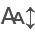

'd:\\GoogleDrive\\phd\\Paper 2'

In [1]:
# import IPython
# IPython.get_ipython().magic('reset -sf')  # Clears memory
import os
import sqlite3
import pandas as pd
import numpy as np
import json
import ast
from scipy.stats import ttest_1samp
import time
from Functions import main

os.getcwd()

In [2]:
#Load result from database
# Connect to the database
conn = sqlite3.connect("./Results/result.db")  # Ensure the correct path
cursor = conn.cursor()

# Read the table into a Pandas DataFrame
result = pd.read_sql_query("SELECT * FROM XAI", conn)

# Close the connection
conn.close()

result.head()

xai_method background_type  background_size dataset_name   more_info  \
0       Tree          random               10  Residential  house1.csv   
1     Kernel          random               10  Residential  house1.csv   
2       Tree          random               10  Residential  house1.csv   
3     Kernel          random               10  Residential  house1.csv   
4       Tree          random               10  Residential  house1.csv   

  model_type  row_id                                            shap_df  \
0        GRU   13861  {"Hour":{"0":-0.000289516,"1":-0.0019543953,"2...   
1        GRU   13861  {"Hour":{"0":-0.0597682676,"1":-0.0380021261,"...   
2        GRU   23990  {"Hour":{"0":-0.000105923,"1":-0.0012578196,"2...   
3        GRU   23990  {"Hour":{"0":-0.0086821296,"1":0.0043870608,"2...   
4        GRU    8831  {"Hour":{"0":0.0012534942,"1":0.0025413528,"2"...   

                                        anomaly_data  \
0  {"0":{"0":0.7391304348,"1":0.7826086957,"2":0....   
1  {"0":{"0":0.7391304348,"1":0.7826086957,"2":0....   
2  {"0":{"0":0.652173913,"1":0.6956521739,"2":0.7...   
3  {"0":{"0":0.652173913,"1":0.6956521739,"2":0.7...   
4  {"0":{"0":0.0869565217,"1":0.1304347826,"2":0....   

                                 background_training  baseline_real  \
0  {"0":{"0":0.652173913,"1":0.5217391304,"2":0.7...       3.525421   
1  {"0":{"0":0.1739130435,"1":0.0434782609,"2":0....       3.525421   
2  {"0":{"0":0.8695652174,"1":0.2608695652,"2":0....       3.455613   
3  {"0":{"0":0.2608695652,"1":0.347826087,"2":0.3...       3.455613   
4  {"0":{"0":0.652173913,"1":0.7391304348,"2":0.6...       3.490343   

   baseline_prediction  baseline_error  \
0             3.958561        0.433139   
1             4.182388        0.656966   
2             3.972922        0.517309   
3             3.786181        0.330568   
4             4.047587        0.557244   

                                       features_name  calculation_time  \
0  ["Hour", "DayOfWeek", "DayOfMonth", "Month", "...          0.000000   
1  ["Hour", "DayOfWeek", "DayOfMonth", "Month", "...          3.906425   
2  ["Hour", "DayOfWeek", "DayOfMonth", "Month", "...          0.015597   
3  ["Hour", "DayOfWeek", "DayOfMonth", "Month", "...          4.031034   
4  ["Hour", "DayOfWeek", "DayOfMonth", "Month", "...          0.000000   

  data_type  
0  original  
1  original  
2  original  
3  original  
4  original

# Table I

In [4]:
import sqlite3
import pandas as pd
import numpy as np
import os

def generate_summary_table():
    """
    Generates a table summarizing the mean and standard deviation of calculation time
    for each XAI method across different datasets, rounded up to two decimal places.

    Returns:
    - DataFrame: Summary table with datasets as columns and XAI methods as rows.
    """

    database_path = "./Results/result.db"
    if not os.path.exists(database_path):
        print(f"❌ Error: Database file not found at {database_path}. Check the path.")
        return None

    # Load result from database
    conn = sqlite3.connect(database_path)
    result = pd.read_sql_query("SELECT * FROM XAI", conn)
    conn.close()

    # Get unique dataset names
    dataset_types = result['dataset_name'].dropna().unique().tolist()

    # Define XAI methods
    xai_methods = ['TDE', 'Kernel', 'Permutation', 'Sampling', 'Partition', 'Lime']

    # Dictionary to store summary data
    summary_data = {}

    for xai_method in xai_methods:
        row_values = {}

        for dataset in dataset_types:
            method_data = result[
                (result['dataset_name'] == dataset) &
                (result['xai_method'] == xai_method)
            ]['calculation_time'].dropna()

            if not method_data.empty:
                mean_time = np.ceil(np.mean(method_data) * 100) / 100  # Round up to 2 decimal places
                std_time = np.ceil(np.std(method_data) * 100) / 100    # Round up to 2 decimal places
                row_values[dataset] = f"{mean_time:.2f} ± {std_time:.2f}"
            else:
                row_values[dataset] = "N/A"

        summary_data[xai_method] = row_values

    # Convert to DataFrame
    summary_df = pd.DataFrame.from_dict(summary_data, orient='index')

    return summary_df

# Generate and display the summary table
summary_table = generate_summary_table()
summary_table

Residential Manufacturing facility  Office building  \
TDE              0.02 ± 0.04            0.06 ± 0.29      0.01 ± 0.01   
Kernel           7.53 ± 7.84            7.93 ± 9.88     9.49 ± 10.39   
Permutation      9.36 ± 9.91          10.45 ± 12.25    23.20 ± 39.44   
Sampling     284.85 ± 254.38        314.82 ± 297.44  721.60 ± 965.33   
Partition        4.71 ± 2.83            4.87 ± 2.72      6.26 ± 5.72   
Lime             2.65 ± 2.20            2.95 ± 2.35      4.65 ± 5.31   

                Retail store   Medical clinic  
TDE              0.02 ± 0.01      0.02 ± 0.01  
Kernel          9.95 ± 10.70    18.42 ± 20.46  
Permutation    18.08 ± 24.26    18.06 ± 25.89  
Sampling     655.56 ± 703.47  518.63 ± 692.06  
Partition        4.94 ± 3.63      4.79 ± 3.47  
Lime             3.57 ± 3.59      3.50 ± 3.52

# Fig2

✅ Plot saved as Calculation_Time.pdf


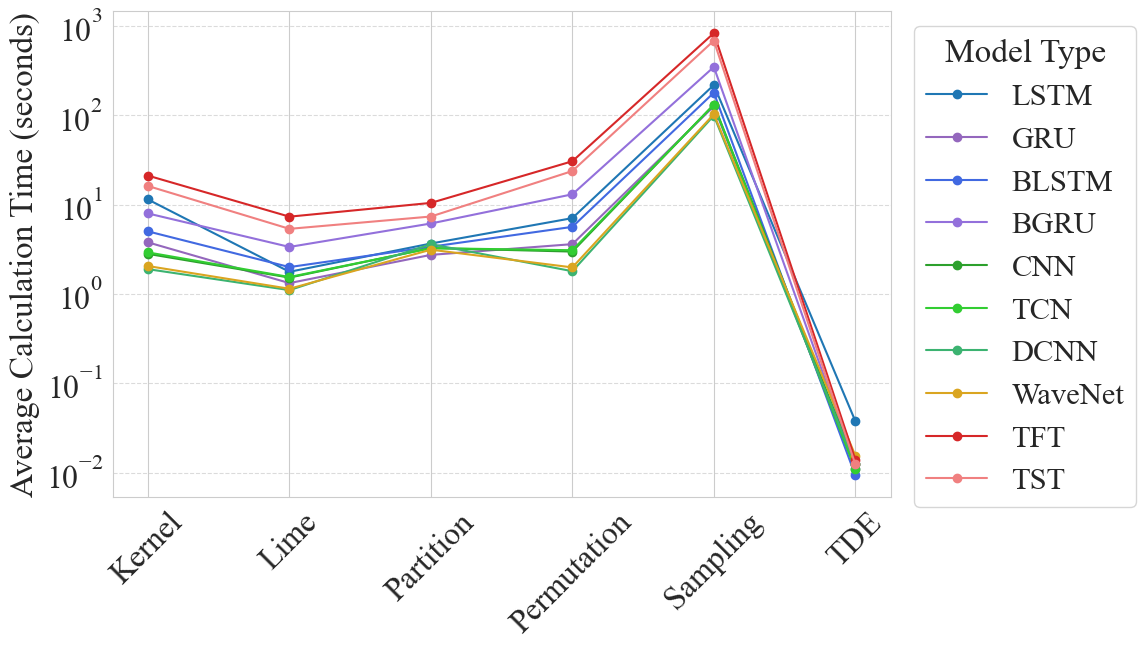


📊 Calculation Time Summary (Plotted Data):
model_type     BGRU   BLSTM     CNN    DCNN     GRU    LSTM     TCN     TFT  \
xai_method                                                                    
Kernel         8.00    6.00    3.00    2.00    4.00   12.00    3.00   22.00   
Lime           4.00    3.00    2.00    2.00    2.00    2.00    2.00    8.00   
Partition      7.00    4.00    4.00    4.00    3.00    4.00    4.00   11.00   
Permutation   14.00    6.00    3.00    2.00    4.00    8.00    4.00   31.00   
Sampling     348.00  179.00  132.00  100.00  126.00  219.00  131.00  831.00   
TDE            1.00    1.00    1.00    1.00    1.00    1.00    1.00    1.00   

model_type      TST WaveNet  
xai_method                   
Kernel        17.00    3.00  
Lime           6.00    2.00  
Partition      8.00    4.00  
Permutation   24.00    2.00  
Sampling     684.00  103.00  
TDE            1.00    1.00  


model_type     BGRU   BLSTM     CNN    DCNN     GRU    LSTM     TCN     TFT  \
xai_method                                                                    
Kernel         8.00    6.00    3.00    2.00    4.00   12.00    3.00   22.00   
Lime           4.00    3.00    2.00    2.00    2.00    2.00    2.00    8.00   
Partition      7.00    4.00    4.00    4.00    3.00    4.00    4.00   11.00   
Permutation   14.00    6.00    3.00    2.00    4.00    8.00    4.00   31.00   
Sampling     348.00  179.00  132.00  100.00  126.00  219.00  131.00  831.00   
TDE            1.00    1.00    1.00    1.00    1.00    1.00    1.00    1.00   

model_type      TST WaveNet  
xai_method                   
Kernel        17.00    3.00  
Lime           6.00    2.00  
Partition      8.00    4.00  
Permutation   24.00    2.00  
Sampling     684.00  103.00  
TDE            1.00    1.00

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set this once to control all font sizes
user_font_size = 24  # You can change this value to 12, 16, etc.

# Apply global font configuration
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': user_font_size,
    'axes.titlesize': user_font_size + 2,
    'axes.labelsize': user_font_size,
    'xtick.labelsize': user_font_size - 1,
    'ytick.labelsize': user_font_size - 1,
    'legend.fontsize': user_font_size -2,
    'legend.title_fontsize': user_font_size,
})

# Define model color mapping based on user preference
model_color_map = {
    "LSTM": "tab:blue", "BLSTM": "royalblue",
    "GRU": "tab:purple", "BGRU": "mediumpurple",
    "CNN": "tab:green", "DCNN": "mediumseagreen", "TCN": "limegreen",
    "WaveNet": "goldenrod",
    "TFT": "tab:red", "TST": "lightcoral"
}

# Define the correct order for legend display
model_order = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']

def plot_avg_xai_timing_line(dataset_name, xai_methods, result_df, save_pdf=True, pdf_filename="Calculation_Time.pdf"):
    """
    Plots the average calculation time for each XAI method in a given dataset using a line plot,
    with separate lines for each model type.
    """
    
    required_columns = {"dataset_name", "xai_method", "model_type", "calculation_time"}
    if not required_columns.issubset(result_df.columns):
        print("❌ Required columns are missing in the dataset.")
        return None

    result_df["calculation_time"] = pd.to_numeric(result_df["calculation_time"], errors="coerce")

    subset = result_df[
        (result_df["dataset_name"] == dataset_name) & 
        (result_df["xai_method"].isin(xai_methods))
    ]

    if subset.empty:
        print(f"⚠️ No data found for dataset '{dataset_name}' with the specified XAI methods.")
        return None

    avg_timing = subset.groupby(["xai_method", "model_type"])["calculation_time"].mean().reset_index()

    plt.figure(figsize=(12, 7))

    plotted_models = [m for m in model_order if m in avg_timing["model_type"].unique()]

    for model in plotted_models:
        model_subset = avg_timing[avg_timing["model_type"] == model]
        plt.plot(model_subset["xai_method"], model_subset["calculation_time"], 
                 marker="o", linestyle="-", label=model, color=model_color_map.get(model, "black"))

    plt.ylabel("Average Calculation Time (seconds)")
    plt.xticks(rotation=45)
    
    plt.legend(title="Model Type", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.yscale("log")  # Log scale for better visualization
    plt.tight_layout()

    if save_pdf:
        plt.savefig(pdf_filename, format="pdf", bbox_inches="tight", dpi=300)
        print(f"✅ Plot saved as {pdf_filename}")

    plt.show()

    avg_timing["calculation_time"] = avg_timing["calculation_time"].apply(lambda x: f"{np.ceil(x):.2f}")
    table_df = avg_timing.pivot(index="xai_method", columns="model_type", values="calculation_time")

    print("\n📊 Calculation Time Summary (Plotted Data):")
    print(table_df)
    
    return table_df

# Example usage:
dataset_types = ["Residential", "Manufacturing facility"]
xai_methods = ['TDE', 'Kernel', 'Permutation', 'Partition', 'Lime', 'Sampling']

# Assuming 'result' is the DataFrame with relevant data
plot_avg_xai_timing_line(dataset_types[0], xai_methods, result)


# Statistical Comparision with original and random (pairwise)

In [202]:
import sqlite3
import pandas as pd
import numpy as np
from io import StringIO
from scipy.stats import wilcoxon, ttest_rel
from itertools import combinations  # (Not used now, but kept if needed)

# Define database path and parameters
database_path = "./Results/result.db"  # Update path if needed
xai_methods = ['TDE', 'Kernel', 'Permutation', 'Sampling', 'Partition', 'Lime']
dataset_names = ["Residential", "Manufacturing facility", "Office building", "Retail store", "Medical clinic"]

# Read the entire database using a context manager
with sqlite3.connect(database_path) as conn:
    result = pd.read_sql_query("SELECT * FROM XAI", conn)

# Verify that the required columns exist
required_columns = {'xai_method', 'dataset_name', 'data_type', 'row_id', 'model_type', 'shap_df'}
if not required_columns.issubset(result.columns):
    raise ValueError(f"Missing required columns. Expected columns: {required_columns}")

# List to store Mean Absolute Error (MAE) results
mae_list = []

# Iterate over each dataset, XAI method, and model type
for dataset_name in dataset_names:
    for xai_method in xai_methods:
        model_types = result[
            (result['xai_method'] == xai_method) &
            (result['dataset_name'] == dataset_name)
        ]['model_type'].unique()

        for model_type in model_types:
            # Filter subsets for original and random SHAP values
            subset_original = result[
                (result['xai_method'] == xai_method) & 
                (result['dataset_name'] == dataset_name) & 
                (result['model_type'] == model_type) &
                (result['data_type'] == 'original')
            ].reset_index(drop=True)

            subset_random = result[
                (result['xai_method'] == xai_method) & 
                (result['dataset_name'] == dataset_name) & 
                (result['model_type'] == model_type) &
                (result['data_type'] == 'random')
            ].reset_index(drop=True)

            # Merge on row_id to ensure pairing of original and random data
            merged_df = subset_original.merge(subset_random, on='row_id', suffixes=('_original', '_random'))

            if not merged_df.empty:
                mae_values = []
                for _, row in merged_df.iterrows():
                    try:
                        original_df = pd.read_json(StringIO(row['shap_df_original']))
                        random_df = pd.read_json(StringIO(row['shap_df_random']))
                    except Exception as e:
                        # Skip rows with JSON conversion issues
                        continue

                    # Only compute if shapes match
                    if original_df.shape == random_df.shape:
                        # Ensure numeric conversion (coerce errors)
                        original_df = original_df.apply(pd.to_numeric, errors='coerce')
                        random_df = random_df.apply(pd.to_numeric, errors='coerce')
                        # Compute MAE over all cells (first mean over columns, then over rows)
                        mae = (original_df - random_df).abs().mean().mean()
                        mae_values.append(mae)

                if mae_values:
                    mae_list.append({
                        'Dataset': dataset_name,
                        'XAI Method': xai_method,
                        'Model Type': model_type,
                        'Mean Absolute Error': np.mean(mae_values)
                    })

# Convert the list of MAE results into a DataFrame and save to CSV
mae_df = pd.DataFrame(mae_list)
output_path = "./xai_method_model_mae_comparison.csv"
mae_df.to_csv(output_path, index=False)

# -----------------------------
# Pairwise Comparisons (Preserving Order)
# -----------------------------
pairwise_results = []

# Use a double loop over the provided order in xai_methods.
for i in range(len(xai_methods)):
    for j in range(i+1, len(xai_methods)):
        xai1 = xai_methods[i]
        xai2 = xai_methods[j]
        
        # For each dataset, get paired MAE values (by matching Model Type)
        for dataset_name in dataset_names:
            dataset_mae_df = mae_df[mae_df['Dataset'] == dataset_name]
            # Find common model types for which both methods have MAE values
            models_xai1 = set(dataset_mae_df[dataset_mae_df['XAI Method'] == xai1]['Model Type'])
            models_xai2 = set(dataset_mae_df[dataset_mae_df['XAI Method'] == xai2]['Model Type'])
            common_models = sorted(models_xai1.intersection(models_xai2))
            
            if common_models:
                values1 = []
                values2 = []
                for model in common_models:
                    val1 = dataset_mae_df[
                        (dataset_mae_df['XAI Method'] == xai1) & 
                        (dataset_mae_df['Model Type'] == model)
                    ]['Mean Absolute Error'].values
                    val2 = dataset_mae_df[
                        (dataset_mae_df['XAI Method'] == xai2) & 
                        (dataset_mae_df['Model Type'] == model)
                    ]['Mean Absolute Error'].values
                    if len(val1) > 0 and len(val2) > 0:
                        values1.append(val1[0])
                        values2.append(val2[0])
                
                if len(values1) > 1 and len(values2) > 1:  # t-test needs at least 2 paired samples
                    # Perform paired t-test
                    try:
                        stat, p_val = ttest_rel(values1, values2)  # Paired t-test
                    except Exception as e:
                        p_val = np.nan
                    
                    mae_diff = np.mean(values1) - np.mean(values2)
                    
                    # Format p-value with six decimal places and add significance stars
                    significance = ""
                    if p_val < 0.01:
                        significance = "**"
                    elif p_val < 0.05:
                        significance = "*"

                    round_set = 3
                    
                    mae_diff = np.round(mae_diff, round_set)
                    p_val = np.round(p_val, round_set)
                    
                    formatted_result = f"{mae_diff:.3f} ({p_val:.3f}{significance})"
                    pairwise_results.append((xai1, xai2, dataset_name, formatted_result))

# Convert the pairwise test results to a DataFrame
pairwise_df = pd.DataFrame(pairwise_results, columns=['XAI Method 1', 'XAI Method 2', 'Dataset', 'MAE Difference (P-Value)'])

# Set categorical ordering for the XAI Method columns based on the provided list
pairwise_df['XAI Method 1'] = pd.Categorical(pairwise_df['XAI Method 1'], categories=xai_methods, ordered=True)
pairwise_df['XAI Method 2'] = pd.Categorical(pairwise_df['XAI Method 2'], categories=xai_methods, ordered=True)

# Pivot the DataFrame so that each dataset becomes a column, preserving the categorical order
pairwise_pivot = pairwise_df.pivot(index=['XAI Method 1', 'XAI Method 2'], columns='Dataset', values='MAE Difference (P-Value)')
# Reindex rows to follow the order of XAI Method 1 and then XAI Method 2
pairwise_pivot = pairwise_pivot.sort_index(level=['XAI Method 1', 'XAI Method 2'])
pairwise_pivot = pairwise_pivot.reindex(columns=dataset_names)
pairwise_pivot = pairwise_pivot.reset_index()

# Save the pairwise comparison results
pairwise_output_path = "./xai_method_pairwise_comparisons_ttest.csv"
pairwise_pivot.to_csv(pairwise_output_path, index=False)

# Display the final pairwise pivot table
pairwise_pivot


Dataset XAI Method 1 XAI Method 2       Residential Manufacturing facility  \
0                TDE       Kernel  -0.016 (0.000**)        -0.512 (0.012*)   
1                TDE  Permutation  -0.010 (0.000**)       -0.115 (0.000**)   
2                TDE     Sampling  -0.009 (0.000**)       -0.080 (0.000**)   
3                TDE    Partition  -0.002 (0.001**)       -0.101 (0.000**)   
4                TDE         Lime  -0.012 (0.000**)       -0.136 (0.000**)   
5             Kernel  Permutation   0.007 (0.000**)         0.397 (0.029*)   
6             Kernel     Sampling   0.008 (0.000**)         0.432 (0.027*)   
7             Kernel    Partition   0.015 (0.000**)         0.412 (0.034*)   
8             Kernel         Lime    0.005 (0.039*)         0.376 (0.044*)   
9        Permutation     Sampling    0.001 (0.050*)         0.035 (0.021*)   
10       Permutation    Partition   0.008 (0.000**)          0.014 (0.432)   
11       Permutation         Lime    -0.002 (0.170)         -0.021 (0.066)   
12          Sampling    Partition   0.007 (0.000**)         -0.020 (0.206)   
13          Sampling         Lime    -0.003 (0.072)       -0.056 (0.001**)   
14         Partition         Lime  -0.010 (0.000**)         -0.035 (0.063)   

Dataset   Office building      Retail store    Medical clinic  
0          -0.235 (0.096)  -0.001 (0.000**)  -0.033 (0.000**)  
1        -0.042 (0.002**)  -0.001 (0.002**)  -0.014 (0.000**)  
2        -0.028 (0.000**)  -0.001 (0.001**)  -0.012 (0.000**)  
3        -0.042 (0.000**)  -0.000 (0.000**)  -0.006 (0.000**)  
4        -0.058 (0.000**)  -0.001 (0.000**)  -0.012 (0.000**)  
5           0.193 (0.137)    0.000 (0.029*)    0.019 (0.012*)  
6           0.208 (0.136)   0.001 (0.010**)    0.021 (0.013*)  
7           0.193 (0.146)   0.001 (0.001**)   0.026 (0.002**)  
8           0.177 (0.182)    0.000 (0.048*)   0.021 (0.007**)  
9           0.015 (0.132)     0.000 (0.116)     0.002 (0.120)  
10          0.000 (0.937)    0.000 (0.038*)   0.007 (0.000**)  
11        -0.016 (0.025*)    -0.000 (0.425)     0.002 (0.191)  
12         -0.014 (0.054)    0.000 (0.036*)   0.005 (0.002**)  
13       -0.030 (0.001**)    -0.000 (0.115)     0.000 (0.979)  
14       -0.016 (0.001**)  -0.000 (0.007**)  -0.005 (0.001**)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "./xai_method_model_mae_comparison.csv"  # Update path if necessary
df = pd.read_csv(file_path)

# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create bar plot with "Dataset" on x-axis and "XAI Method" as hue
ax = sns.barplot(
    data=df, x="Dataset", y="Mean Absolute Error",
    hue="XAI Method", palette="Set2", dodge=True, errorbar=None  # No error bars
)

# Apply log scale for better visualization
plt.yscale("log")

# Improve aesthetics
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Mean Absolute Error (Log Scale)", fontsize=12)
plt.title("Comparison of XAI Methods based on MAE", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.legend(title="XAI Method", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.tight_layout()

# ✅ Corrected PDF Saving
pdf_filename = "xai_mae_comparison.pdf"
plt.savefig(pdf_filename, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ Plot saved as {pdf_filename}")

# Show plot
plt.show()


# Sensitivity/Robustness

In [216]:
import sqlite3
import pandas as pd
import numpy as np
from io import StringIO
from scipy.stats import kendalltau
import os

def compute_kendall_correlation(summary_method='mean', debug=True):
    """
    Computes Kendall's rank correlation between original and perturbed feature rankings 
    for different XAI methods across multiple datasets.
    
    Parameters:
    summary_method (str): Method to summarize SHAP values ('mean' or 'sum') before ranking.
    debug (bool): If True, prints intermediate results.

    Returns:
    DataFrame: A table with Kendall correlation results for each dataset and XAI method.
    """
    
    database_path = "./Results/result.db"
    if not os.path.exists(database_path):
        print(f"Error: Database file not found at {database_path}. Check the path.")
        return None
    
    # Load dataset from SQLite
    conn = sqlite3.connect(database_path)
    result = pd.read_sql_query("SELECT * FROM XAI", conn)
    conn.close()

    dataset_types = result['dataset_name'].dropna().unique().tolist()
    xai_methods = ['TDE', 'Kernel', 'Permutation', 'Sampling', 'Partition', 'Lime']
    model_types = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']

    dataset_kendall_results = []

    # Iterate over datasets and XAI methods
    for dataset_type in dataset_types:
        for xai_method in xai_methods:
            all_kendall_values = []

            for model_type in model_types:
                subset = result[
                    (result['dataset_name'] == dataset_type) & 
                    (result['xai_method'] == xai_method) & 
                    (result['model_type'] == model_type)
                ].reset_index(drop=True)

                if subset.empty:
                    continue

                for row_id in subset['row_id'].dropna().unique():
                    row_data = subset[subset['row_id'] == row_id]
                    original_data = row_data[row_data['data_type'] == 'original']
                    random_data = row_data[row_data['data_type'] == 'random']

                    if original_data.empty or random_data.empty:
                        continue

                    def extract_rankings(shap_df_series, summary_method):
                        feature_ranks = []
                        for shap_str in shap_df_series.dropna():
                            try:
                                shap_df = pd.read_json(StringIO(shap_str))  
                                if shap_df.empty:
                                    continue
                                
                                # Summarize feature importance across time steps
                                if summary_method == 'mean':
                                    summarized_values = shap_df.mean(axis=1)
                                elif summary_method == 'sum':
                                    summarized_values = shap_df.sum(axis=1)
                                else:
                                    raise ValueError("Invalid summary_method. Choose 'mean' or 'sum'.")

                                # Compute rankings
                                rank_values = summarized_values.rank(ascending=False)
                                feature_ranks.append(rank_values)
                            except:
                                continue
                        return feature_ranks

                    original_ranks = extract_rankings(original_data['shap_df'], summary_method)
                    random_ranks = extract_rankings(random_data['shap_df'], summary_method)

                    if original_ranks and random_ranks:
                        for orig_rank, rand_rank in zip(original_ranks, random_ranks):
                            kendall_corr, _ = kendalltau(orig_rank, rand_rank)
                            if not np.isnan(kendall_corr):
                                all_kendall_values.append(kendall_corr)

            if all_kendall_values:
                avg_kendall = np.mean(all_kendall_values)
            else:
                avg_kendall = np.nan

            dataset_kendall_results.append({
                'Dataset': dataset_type,
                'XAI Method': xai_method,
                'Kendall Correlation': avg_kendall
            })

    # Convert results to DataFrame
    kendall_df = pd.DataFrame(dataset_kendall_results)

    # Pivot table for better readability
    kendall_pivot = kendall_df.pivot(index='Dataset', columns='XAI Method', values='Kendall Correlation')

    # Save results
    output_path = f"./kendall_correlation_results_{summary_method}.csv"
    kendall_pivot.to_csv(output_path)
    print(f"Kendall correlation results saved to {output_path}")

    return kendall_pivot

# Example usage:
kendall_results_mean = compute_kendall_correlation(summary_method='mean', debug=False)
# kendall_results_sum = compute_kendall_correlation(summary_method='sum', debug=False)
kendall_results_sum

Kendall correlation results saved to ./kendall_correlation_results_mean.csv


XAI Method                Kernel      Lime  Partition  Permutation  Sampling  \
Dataset                                                                        
Manufacturing facility  0.335642  0.307828   0.021618     0.432021  0.548865   
Medical clinic          0.423380  0.388696   0.053168     0.547092  0.622270   
Office building         0.415609  0.435287   0.003573     0.560745  0.599539   
Residential             0.308249  0.121481   0.057378     0.421809  0.410461   
Retail store            0.525092  0.341439   0.019468     0.680851  0.700922   

XAI Method                   TDE  
Dataset                           
Manufacturing facility  0.798132  
Medical clinic          0.765359  
Office building         0.736401  
Residential             0.734396  
Retail store            0.856282

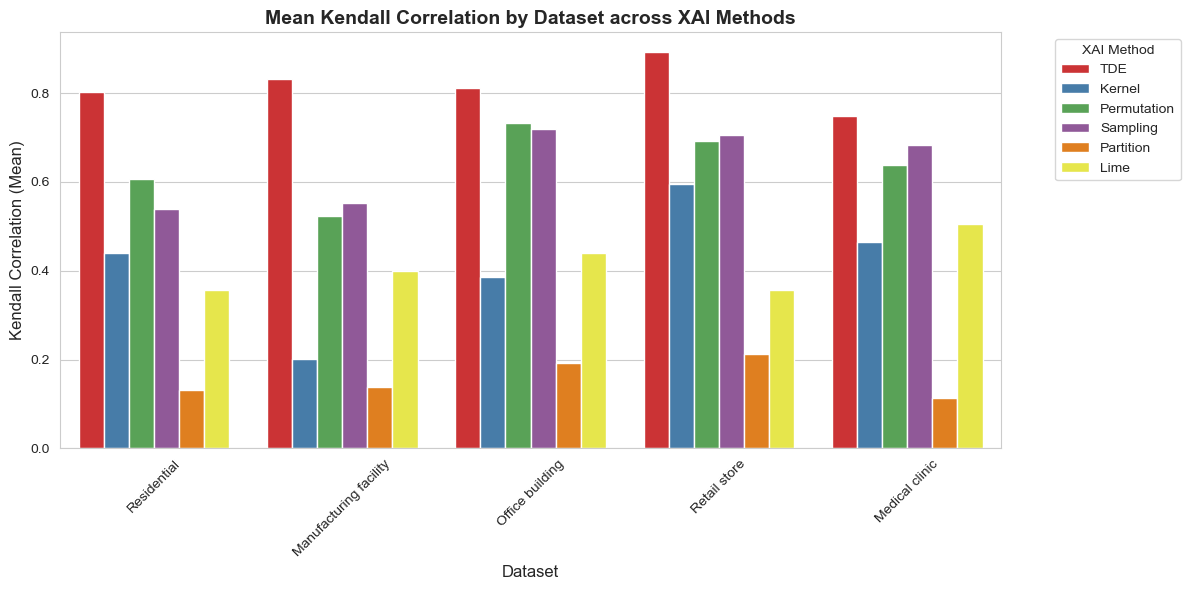

Total rows in kendall_df: 1503
Dataset Residential, Method TDE: 50 values, Mean: 0.803
Dataset Residential, Method Kernel: 50 values, Mean: 0.439
Dataset Residential, Method Permutation: 50 values, Mean: 0.607
Dataset Residential, Method Sampling: 50 values, Mean: 0.540
Dataset Residential, Method Partition: 50 values, Mean: 0.132
Dataset Residential, Method Lime: 50 values, Mean: 0.357
Dataset Manufacturing facility, Method TDE: 53 values, Mean: 0.831
Dataset Manufacturing facility, Method Kernel: 50 values, Mean: 0.202
Dataset Manufacturing facility, Method Permutation: 50 values, Mean: 0.523
Dataset Manufacturing facility, Method Sampling: 50 values, Mean: 0.552
Dataset Manufacturing facility, Method Partition: 50 values, Mean: 0.139
Dataset Manufacturing facility, Method Lime: 50 values, Mean: 0.399
Dataset Office building, Method TDE: 50 values, Mean: 0.811
Dataset Office building, Method Kernel: 50 values, Mean: 0.385
Dataset Office building, Method Permutation: 50 values, Mean: 

In [337]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
from scipy.stats import kendalltau
import os
import json

# Database path
database_path = "./Results/result.db"  # Update this path if you meant a different dataset location

if not os.path.exists(database_path):
    print(f"Error: Database file not found at {database_path}. Check the path.")
    exit()

# Load data from database
conn = sqlite3.connect(database_path)
result = pd.read_sql_query("SELECT * FROM XAI", conn)
conn.close()

# Define datasets, XAI methods, and model types
dataset_types = result['dataset_name'].dropna().unique().tolist()
xai_methods = ['TDE', 'Kernel', 'Permutation', 'Sampling', 'Partition', 'Lime']
model_types = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']

# List to store Kendall correlation values for each row ID
kendall_values = []

for dataset_type in dataset_types:
    for xai_method in xai_methods:
        for model_type in model_types:
            subset = result[
                (result['dataset_name'] == dataset_type) & 
                (result['xai_method'] == xai_method) & 
                (result['model_type'] == model_type)
            ].reset_index(drop=True)

            if subset.empty:
                continue

            for row_id in subset['row_id'].dropna().unique():
                row_data = subset[subset['row_id'] == row_id]
                original_data = row_data[row_data['data_type'] == 'original']
                random_data = row_data[row_data['data_type'] == 'random']

                if original_data.empty or random_data.empty:
                    continue

                def process_shap_df(shap_df_series, method):
                    ranks = []
                    for shap_str in shap_df_series.dropna():
                        try:
                            shap_df = pd.read_json(StringIO(shap_str))  
                            if shap_df.empty:
                                continue
                            if method == 'mean':
                                feature_ranks = shap_df.mean().rank(ascending=False)
                            elif method == 'sum':
                                feature_ranks = shap_df.sum().rank(ascending=False)
                            else:
                                continue
                            ranks.append(feature_ranks)
                        except (ValueError, json.JSONDecodeError):
                            continue
                    return ranks

                original_ranks = process_shap_df(original_data['shap_df'], method="mean")
                random_ranks = process_shap_df(random_data['shap_df'], method="mean")

                if original_ranks and random_ranks:
                    # Compute Kendall correlation for each valid pair of rankings
                    for orig_rank, rand_rank in zip(original_ranks, random_ranks):
                        kendall_corr, _ = kendalltau(orig_rank, rand_rank)
                        if not np.isnan(kendall_corr):
                            kendall_values.append({
                                "Dataset": dataset_type,
                                "XAI Method": xai_method,
                                "Kendall Correlation": kendall_corr
                            })

# Convert list to DataFrame
kendall_df = pd.DataFrame(kendall_values)

# Define dataset types explicitly (based on your image)
dataset_types = ['Residential', 'Manufacturing facility', 'Office building', 'Retail store', 'Medical clinic']

# -----------------------------
# 📊 Generate the Bar Plot
# -----------------------------
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create a bar plot with mean Kendall Correlation per dataset, split by XAI method
sns.barplot(
    data=kendall_df,
    x="Dataset",
    y="Kendall Correlation",
    hue="XAI Method",  # Different colors for each XAI method
    estimator=np.mean,  # Use mean as the central tendency
    errorbar=None,  # Remove error bars as requested
    palette="Set1",  # Use a distinguishable color palette
)

# Improve aesthetics
plt.xlabel("Dataset", fontsize=12)
plt.ylabel("Kendall Correlation (Mean)", fontsize=12)
plt.title("Mean Kendall Correlation by Dataset across XAI Methods", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.legend(title="XAI Method", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show plot
plt.savefig("kendall_correlation_barplot.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Debug: Verify data
print(f"Total rows in kendall_df: {len(kendall_df)}")
for dataset in dataset_types:
    for xai_method in xai_methods:
        dataset_method_data = kendall_df[(kendall_df['Dataset'] == dataset) & (kendall_df['XAI Method'] == xai_method)]['Kendall Correlation'].dropna()
        print(f"Dataset {dataset}, Method {xai_method}: {len(dataset_method_data)} values, Mean: {dataset_method_data.mean():.3f}")

In [278]:
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3
import os
from io import StringIO
from scipy.stats import kendalltau, wilcoxon

# Database path
database_path = "./Results/result.db"

if not os.path.exists(database_path):
    print(f"Error: Database file not found at {database_path}. Check the path.")
    exit()

# Load data from database
conn = sqlite3.connect(database_path)
result = pd.read_sql_query("SELECT * FROM XAI", conn)
conn.close()

# Define datasets, XAI methods (in predefined order), and model types
dataset_types = result['dataset_name'].dropna().unique().tolist()
xai_methods = ['TDE', 'Kernel', 'Permutation', 'Sampling', 'Partition', 'Lime']  # Order preserved
model_types = ['LSTM', 'GRU', 'BLSTM', 'BGRU', 'CNN', 'TCN', 'DCNN', 'WaveNet', 'TFT', 'TST']

# Store Kendall correlations
kendall_values = []

for dataset_type in dataset_types:
    for xai_method in xai_methods:
        for model_type in model_types:
            subset = result[
                (result['dataset_name'] == dataset_type) & 
                (result['xai_method'] == xai_method) & 
                (result['model_type'] == model_type)
            ].reset_index(drop=True)

            if subset.empty:
                continue

            for row_id in subset['row_id'].dropna().unique():
                row_data = subset[subset['row_id'] == row_id]
                original_data = row_data[row_data['data_type'] == 'original']
                random_data = row_data[row_data['data_type'] == 'random']

                if original_data.empty or random_data.empty:
                    continue

                def process_shap_df(shap_df_series, method):
                    ranks = []
                    for shap_str in shap_df_series.dropna():
                        try:
                            shap_df = pd.read_json(StringIO(shap_str))  
                            if shap_df.empty:
                                continue
                            if method == 'mean':
                                feature_ranks = shap_df.mean().rank(ascending=False)
                            elif method == 'sum':
                                feature_ranks = shap_df.sum().rank(ascending=False)
                            else:
                                continue
                            ranks.append(feature_ranks)
                        except (ValueError, json.JSONDecodeError):
                            continue
                    return ranks

                original_ranks = process_shap_df(original_data['shap_df'], method="mean")
                random_ranks = process_shap_df(random_data['shap_df'], method="mean")

                if original_ranks and random_ranks:
                    for orig_rank, rand_rank in zip(original_ranks, random_ranks):
                        kendall_corr, _ = kendalltau(orig_rank, rand_rank)
                        if not np.isnan(kendall_corr):
                            kendall_values.append({
                                "Dataset": dataset_type,
                                "XAI Method": xai_method,
                                "Kendall Correlation": kendall_corr
                            })

# Convert to DataFrame
kendall_df = pd.DataFrame(kendall_values)

# -----------------------------
# 📌 Compute Wilcoxon Signed-Rank Test for Pairwise Comparisons (Preserving Order)
# -----------------------------
pairwise_results = []

for i in range(len(xai_methods)):
    for j in range(i+1, len(xai_methods)):
        xai1 = xai_methods[i]
        xai2 = xai_methods[j]

        for dataset in dataset_types:
            kendall_xai1 = kendall_df[(kendall_df["XAI Method"] == xai1) & (kendall_df["Dataset"] == dataset)]["Kendall Correlation"].values
            kendall_xai2 = kendall_df[(kendall_df["XAI Method"] == xai2) & (kendall_df["Dataset"] == dataset)]["Kendall Correlation"].values

            if len(kendall_xai1) > 0 and len(kendall_xai2) > 0:
                try:
                    stat, p_val = wilcoxon(kendall_xai1, kendall_xai2)
                    if np.isnan(p_val):  # Handling cases where Wilcoxon test fails due to identical values
                        p_val = 1.0
                except:
                    p_val = 1.0  # Assign high p-value if the test fails

                mean_diff = np.mean(kendall_xai1) - np.mean(kendall_xai2)

                significance = ""
                if p_val < 0.01:
                    significance = "**"
                elif p_val < 0.05:
                    significance = "*"

                formatted_result = f"{mean_diff:.3f} ({p_val:.3f}{significance})"
                pairwise_results.append((xai1, xai2, dataset, formatted_result))

# Convert pairwise results to DataFrame
pairwise_df = pd.DataFrame(pairwise_results, columns=["XAI Method 1", "XAI Method 2", "Dataset", "Kendall Difference (P-Value)"])

# Pivot for LaTeX format
pairwise_pivot = pairwise_df.pivot(index=["XAI Method 1", "XAI Method 2"], columns="Dataset", values="Kendall Difference (P-Value)")
pairwise_pivot = pairwise_pivot.reset_index()

# Save CSV for reference
pairwise_pivot.to_csv("./kendall_correlation_wilcoxon_comparison.csv", index=False)
print("Wilcoxon pairwise comparison results saved as CSV.")
pairwise_pivot

Wilcoxon pairwise comparison results saved as CSV.


Dataset XAI Method 1 XAI Method 2 Manufacturing facility    Medical clinic  \
0             Kernel         Lime       -0.197 (0.002**)    -0.042 (0.432)   
1             Kernel    Partition          0.063 (0.393)   0.351 (0.000**)   
2             Kernel  Permutation       -0.321 (0.000**)  -0.174 (0.000**)   
3             Kernel     Sampling       -0.350 (0.000**)  -0.219 (0.000**)   
4          Partition         Lime       -0.261 (0.000**)  -0.393 (0.000**)   
5        Permutation         Lime          0.124 (0.054)   0.132 (0.008**)   
6        Permutation    Partition        0.384 (0.000**)   0.525 (0.000**)   
7        Permutation     Sampling         -0.029 (0.484)   -0.045 (0.043*)   
8           Sampling         Lime         0.153 (0.019*)   0.177 (0.001**)   
9           Sampling    Partition        0.413 (0.000**)   0.570 (0.000**)   
10               TDE       Kernel          0.630 (1.000)   0.283 (0.000**)   
11               TDE         Lime          0.432 (1.000)   0.241 (0.000**)   
12               TDE    Partition          0.693 (1.000)   0.634 (0.000**)   
13               TDE  Permutation          0.309 (1.000)   0.109 (0.008**)   
14               TDE     Sampling          0.279 (1.000)     0.064 (0.096)   

Dataset   Office building       Residential      Retail store  
0          -0.055 (0.257)     0.082 (0.095)   0.238 (0.000**)  
1         0.193 (0.000**)   0.307 (0.000**)   0.383 (0.000**)  
2        -0.347 (0.000**)  -0.168 (0.000**)   -0.097 (0.012*)  
3        -0.335 (0.000**)  -0.100 (0.008**)  -0.111 (0.000**)  
4        -0.248 (0.002**)  -0.225 (0.002**)    -0.145 (0.081)  
5         0.292 (0.000**)   0.250 (0.000**)   0.336 (0.000**)  
6         0.540 (0.000**)   0.475 (0.000**)   0.480 (0.000**)  
7           0.012 (0.852)     0.068 (0.135)    -0.013 (0.474)  
8         0.280 (0.000**)   0.182 (0.002**)   0.349 (0.000**)  
9         0.528 (0.000**)   0.407 (0.000**)   0.493 (0.000**)  
10        0.427 (0.000**)   0.364 (0.000**)   0.298 (0.000**)  
11        0.372 (0.000**)   0.446 (0.000**)   0.536 (0.000**)  
12        0.620 (0.000**)   0.671 (0.000**)   0.681 (0.000**)  
13         0.080 (0.022*)   0.196 (0.000**)   0.201 (0.000**)  
14         0.091 (0.021*)   0.264 (0.000**)   0.187 (0.000**)

In [379]:
import sqlite3
import pandas as pd
import numpy as np
from io import StringIO
from scipy.stats import kruskal, kendalltau
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os
from itertools import combinations

def analyze_xai_kruskal_tukey():
    # Configuration
    database_path = "./Results/result.db"
    dataset_types = ["Residential", "Manufacturing facility", 
                    "Office building", "Retail store", "Medical clinic"]
    xai_methods = ['TDE', 'Kernel', 'Permutation', 'Sampling', 'Partition', 'Lime']
    sorted_methods = ['TDE'] + sorted([m for m in xai_methods if m != 'TDE'])

    if not os.path.exists(database_path):
        print(f"❌ Error: Database file not found at {database_path}")
        return None, None

    # Load data
    conn = sqlite3.connect(database_path)
    result = pd.read_sql_query("SELECT * FROM XAI", conn)
    conn.close()

    # Initialize results storage
    kruskal_results = []
    all_tukey = []

    # Main analysis loop
    for dataset in dataset_types:
        dataset_data = []
        
        # Collect Kendall correlations
        for method in sorted_methods:
            subset = result[(result['dataset_name'] == dataset) & (result['xai_method'] == method)]
            correlations = []
            
            for row_id in subset['row_id'].unique():
                row_subset = subset[subset['row_id'] == row_id]
                original = row_subset[row_subset['data_type'] == 'original']
                random = row_subset[row_subset['data_type'] == 'random']
                
                if not original.empty and not random.empty:
                    try:
                        orig_values = pd.read_json(StringIO(original['shap_df'].iloc[0])).mean()
                        rand_values = pd.read_json(StringIO(random['shap_df'].iloc[0])).mean()
                        corr, _ = kendalltau(orig_values.rank(ascending=False), rand_values.rank(ascending=False))
                        if not np.isnan(corr):
                            correlations.append(corr)
                    except Exception:
                        continue
            
            if correlations:
                dataset_data.extend([[method, corr] for corr in correlations])

        # Statistical tests
        if len(dataset_data) > 1:
            df = pd.DataFrame(dataset_data, columns=['Method', 'Correlation'])
            groups = [df[df['Method'] == m]['Correlation'].values 
                     for m in sorted_methods if m in df['Method'].values]
            
            if len(groups) > 1:
                # Kruskal-Wallis test
                h_stat, p_val = kruskal(*groups)
                kruskal_results.append({
                    'Dataset': dataset, 
                    'Statistic': h_stat, 
                    'P-Value': p_val
                })

                # Tukey's HSD if significant
                if p_val < 0.05:
                    tukey = pairwise_tukeyhsd(
                        endog=df['Correlation'],
                        groups=df['Method'],
                        alpha=0.05
                    )
                    tukey_df = pd.DataFrame(tukey.summary().data[1:], 
                                          columns=tukey.summary().data[0])
                    tukey_df['Dataset'] = dataset
                    
                    # Formatting and significance markers
                    tukey_df['p-adj'] = tukey_df['p-adj'].astype(float)
                    tukey_df['formatted'] = tukey_df.apply(
                        lambda x: f"{x['meandiff']:.3f} ({x['p-adj']:.3f}" + 
                        ("**" if x['p-adj'] < 0.01 else "*" if x['p-adj'] < 0.05 else "") + ")",
                        axis=1
                    )
                    all_tukey.append(tukey_df[['Dataset', 'group1', 'group2', 'formatted']])

    # Process Kruskal results
    kruskal_df = pd.DataFrame(kruskal_results)[['Dataset', 'Statistic', 'P-Value']]
    
    # Process Tukey results
    tukey_final = pd.DataFrame()
    if all_tukey:
        # Combine results and fix TDE ordering
        tukey_combined = pd.concat(all_tukey)
        
        # Function to ensure TDE is always first in pairs
        def fix_tde_pairs(row):
            g1, g2 = row['group1'], row['group2']
            formatted = row['formatted']
            
            if g2 == 'TDE':
                # Swap pairs and invert mean difference
                new_g1, new_g2 = 'TDE', g1
                try:
                    mean_diff = float(formatted.split()[0])
                    # new_mean_diff = -mean_diff
                    formatted = f"{mean_diff:.3f} ({formatted.split('(')[1]}"
                except:
                    pass
                return pd.Series([new_g1, new_g2, formatted])
            return pd.Series([g1, g2, formatted])
        
        # Apply correction
        fixed_pairs = tukey_combined.apply(fix_tde_pairs, axis=1)
        fixed_pairs.columns = ['Method 1', 'Method 2', 'formatted']
        fixed_pairs['Dataset'] = tukey_combined['Dataset']
        
        # Create all possible TDE-first pairs
        all_pairs = pd.DataFrame(
            [('TDE', m) for m in sorted_methods if m != 'TDE'] + 
            list(combinations([m for m in sorted_methods if m != 'TDE'], 2)),
            columns=['Method 1', 'Method 2']
        )
        
        # Pivot to wide format
        pivot_df = fixed_pairs.pivot_table(
            index=['Method 1', 'Method 2'],
            columns='Dataset',
            values='formatted',
            aggfunc='first'
        ).reset_index()
        
        # Merge with all possible pairs
        tukey_final = all_pairs.merge(
            pivot_df, 
            on=['Method 1', 'Method 2'],
            how='left'
        )
        
        # Fill missing datasets and ensure column order
        for ds in dataset_types:
            if ds not in tukey_final:
                tukey_final[ds] = ''
        tukey_final = tukey_final[['Method 1', 'Method 2'] + dataset_types]
        tukey_final = tukey_final.fillna('')

    # Save results
    kruskal_df.to_csv("./kruskal_results.csv", index=False)
    if not tukey_final.empty:
        tukey_final.to_csv("./tukey_results_wide.csv", index=False)
        print("✅ Results saved:")
        print("Kruskal-Wallis Results:")
        print(kruskal_df)
        print("\nTukey HSD Results:")
        print(tukey_final.head())
    else:
        print("ℹ️ No significant Tukey results found")
        
    return kruskal_df, tukey_final

# Execute analysis
kruskal_results, tukey_results = analyze_xai_kruskal_tukey()

✅ Results saved:
Kruskal-Wallis Results:
                  Dataset   Statistic       P-Value
0             Residential  117.748814  9.406776e-24
1  Manufacturing facility  140.527769  1.381919e-28
2         Office building  127.545257  7.895671e-26
3            Retail store  133.249529  4.861725e-27
4          Medical clinic  111.496380  1.977929e-22

Tukey HSD Results:
  Method 1     Method 2      Residential Manufacturing facility  \
0      TDE       Kernel  0.364 (0.000**)        0.630 (0.000**)   
1      TDE         Lime  0.446 (0.000**)        0.432 (0.000**)   
2      TDE    Partition  0.671 (0.000**)        0.693 (0.000**)   
3      TDE  Permutation  0.196 (0.005**)        0.309 (0.000**)   
4      TDE     Sampling  0.264 (0.000**)        0.279 (0.000**)   

   Office building     Retail store   Medical clinic  
0  0.429 (0.000**)  0.298 (0.000**)  0.283 (0.000**)  
1  0.363 (0.000**)  0.536 (0.000**)  0.236 (0.000**)  
2  0.628 (0.000**)  0.681 (0.000**)  0.645 (0.000**)  
3   

In [371]:
kruskal_results

Dataset   Statistic       P-Value
0             Residential  117.748814  9.406776e-24
1  Manufacturing facility  140.527769  1.381919e-28
2         Office building  127.545257  7.895671e-26
3            Retail store  133.249529  4.861725e-27
4          Medical clinic  111.496380  1.977929e-22

In [381]:
tukey_results

Method 1     Method 2       Residential Manufacturing facility  \
0           TDE       Kernel   0.364 (0.000**)        0.630 (0.000**)   
1           TDE         Lime   0.446 (0.000**)        0.432 (0.000**)   
2           TDE    Partition   0.671 (0.000**)        0.693 (0.000**)   
3           TDE  Permutation   0.196 (0.005**)        0.309 (0.000**)   
4           TDE     Sampling   0.264 (0.000**)        0.279 (0.000**)   
5        Kernel         Lime    -0.082 (0.660)        0.197 (0.005**)   
6        Kernel    Partition  -0.307 (0.000**)         -0.063 (0.862)   
7        Kernel  Permutation    0.168 (0.027*)        0.321 (0.000**)   
8        Kernel     Sampling     0.100 (0.443)        0.350 (0.000**)   
9          Lime    Partition  -0.225 (0.001**)       -0.261 (0.000**)   
10         Lime  Permutation   0.250 (0.000**)          0.124 (0.224)   
11         Lime     Sampling    0.182 (0.012*)          0.153 (0.066)   
12    Partition  Permutation   0.475 (0.000**)        0.384 (0.000**)   
13    Partition     Sampling   0.407 (0.000**)        0.413 (0.000**)   
14  Permutation     Sampling    -0.068 (0.816)          0.029 (0.995)   

     Office building      Retail store    Medical clinic  
0    0.429 (0.000**)   0.298 (0.000**)   0.283 (0.000**)  
1    0.363 (0.000**)   0.536 (0.000**)   0.236 (0.000**)  
2    0.628 (0.000**)   0.681 (0.000**)   0.645 (0.000**)  
3      0.079 (0.699)   0.201 (0.003**)     0.102 (0.317)  
4      0.093 (0.529)   0.187 (0.008**)     0.055 (0.879)  
5      0.066 (0.831)  -0.238 (0.000**)     0.047 (0.932)  
6   -0.199 (0.004**)  -0.383 (0.000**)  -0.363 (0.000**)  
7    0.350 (0.000**)     0.098 (0.468)   0.181 (0.004**)  
8    0.336 (0.000**)     0.111 (0.322)   0.228 (0.000**)  
9   -0.265 (0.000**)    -0.145 (0.084)  -0.410 (0.000**)  
10   0.284 (0.000**)   0.336 (0.000**)     0.134 (0.081)  
11   0.270 (0.000**)   0.349 (0.000**)   0.181 (0.004**)  
12   0.549 (0.000**)   0.480 (0.000**)   0.544 (0.000**)  
13   0.535 (0.000**)   0.493 (0.000**)   0.591 (0.000**)  
14    -0.014 (1.000)     0.013 (1.000)     0.047 (0.934)